# STEP 4. 기초 EDA

지금까지 만든 패널이 **말이 되는 데이터인지** 확인하고, 이후 단계의 밑그림을 그립니다. 여기서는 결론을 내지 않습니다 — 어디를 파야 하는지만 정합니다.

| 절 | 보는 것 | 어느 질문의 예고편인가 |
|---|---|---|
| 4-1 | 표본 구성 | — |
| 4-2 | 업종별 순감소율 | **H2** 처리군 후보 |
| 4-3 | 자치구별 순감소율 | **핵심 질문** |
| 4-4 | 상권유형 × 업종 | **H1** |
| 4-5 | 분포와 로그 변환 | 매칭 안정성 |
| 4-6 | 공변량 상관 · VIF | 성향점수 모형 |
| 4-7 | 특성별 순감소율 | **보조질문 2** |

> ⚠️ STEP 3 에서 점포수 기준이 총수로 바뀌며 표본이 20.9% 늘었고, 유입이 프랜차이즈 밀집 업종에 쏠려 있습니다. **이전 실행의 업종별 순위와 다를 수 있습니다.**


In [ ]:
import sys, os
from pathlib import Path

# 노트북이 어디서 열리든 프로젝트 루트를 찾아 sys.path에 추가
ROOT = Path.cwd()
while not (ROOT / "config.py").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
os.chdir(ROOT)

import numpy as np
import pandas as pd
pd.set_option("display.width", 220)
pd.set_option("display.max_columns", 60)
print("프로젝트 루트:", ROOT)

프로젝트 루트: /tmp/p2


In [ ]:
import matplotlib.pyplot as plt
from config import PROC, FIG, FOOD, TARGET_TYPE, COVARIATES, set_korean_font
set_korean_font()
OUT = FIG.parent

d = pd.read_pickle(PROC / "03_panel.pkl")

# STEP 2에서 만든 임시 컬럼이 남아 있으면 정리 (매출_관측 과 동일한 정보)
d = d.drop(columns=[c for c in ["매출결측"] if c in d.columns])

gm = d[d["상권유형"] == TARGET_TYPE]
print(f"패널 {d.shape} | 순감소율 {d['y'].mean():.1%}")
print(f"{TARGET_TYPE} {len(gm):,}행 | 순감소율 {gm['y'].mean():.1%}")

패널 (67475, 36) | 순감소율 25.5%
골목상권 34,647행 | 순감소율 23.6%


## 4-1. 표본 구성

**관광특구는 상권이 6개뿐입니다.** 칸 수는 수백 개로 보이지만 독립적인 상권은 6개라, 여기서 나오는 어떤 수치도 별도 결론으로 쓰지 않습니다.

In [ ]:
t = (d.groupby("상권유형")
     .agg(칸수=("y", "size"), 상권수=("상권_코드", "nunique"),
          순감소율=("y", "mean"), 평균점포=("전체_점포_수", "mean"),
          중앙유동인구=("총_유동인구_수", "median"))
     .sort_values("순감소율", ascending=False))
display(t.round(3))
print("※ 관광특구는 상권 6개 — 칸 수와 무관하게 결론을 내지 않습니다.")

display(d.groupby("기준_년분기_코드")
        .agg(칸수=("y", "size"), 순감소율=("y", "mean")).round(3).T)

,칸수,상권수,순감소율,평균점포,중앙유동인구
상권유형,,,,,
관광특구,696,6,0.378,90.986,4005509.0
발달상권,23011,248,0.292,33.332,1214182.0
골목상권,34647,928,0.236,13.454,1019353.0
전통시장,9121,240,0.224,15.957,434783.0


※ 관광특구는 상권 6개 — 칸 수와 무관하게 결론을 내지 않습니다.


기준_년분기_코드,20231,20232,20233,20234,20241,20242,20243,20244,20251,20252,20253,20254
칸수,5706.000,5731.000,5701.000,5730.000,5706.000,5678.000,5622.000,5586.000,5534.000,5502.00,5500.000,5479.00
순감소율,0.229,0.261,0.223,0.236,0.254,0.276,0.262,0.284,0.261,0.26,0.253,0.26


## 4-2. 업종별 순감소율 — H2 처리군 후보

STEP 5 에서 **가장 높은 업종을 처리군으로 자동 지정**합니다. 미리 정하지 않고 데이터가 고르게 하는 이유는 임의로 골랐다는 인상을 피하기 위해서입니다. 여기서는 그 후보가 무엇이 될지 미리 봅니다.

In [ ]:
def by_svc(frame, label):
    return (frame.groupby("서비스_업종_코드_명")
            .agg(**{f"{label}_순감소율": ("y", "mean"), f"{label}_칸수": ("y", "size")}))

t = by_svc(d, "전체").join(by_svc(gm, "골목"))
t = t.sort_values("골목_순감소율", ascending=False)
display(t.round(3))

print(f"→ {TARGET_TYPE} 최고 위험 업종 : {t.index[0]} ({t.iloc[0]['골목_순감소율']:.1%})")
print(f"   2위 {t.index[1]} ({t.iloc[1]['골목_순감소율']:.1%}) 와 격차 "
      f"{t.iloc[0]['골목_순감소율']-t.iloc[1]['골목_순감소율']:+.1%}p")
print("\n※ 격차가 작으면 처리군 선택이 표본 흔들림에 민감하다는 뜻 — STEP 5에서 확인 필요")

,전체_순감소율,전체_칸수,골목_순감소율,골목_칸수
서비스_업종_코드_명,,,,
한식음식점,0.269,15677,0.253,9957
커피-음료,0.263,12046,0.244,7741
호프-간이주점,0.289,8448,0.239,4596
패스트푸드점,0.239,3901,0.237,1440
양식음식점,0.266,4172,0.228,1478
분식전문점,0.236,7570,0.222,3634
일식음식점,0.256,3696,0.216,1036
제과점,0.225,4133,0.206,1636
치킨전문점,0.205,4186,0.201,1922


→ 골목상권 최고 위험 업종 : 한식음식점 (25.3%)
   2위 커피-음료 (24.4%) 와 격차 +0.9%p

※ 격차가 작으면 처리군 선택이 표본 흔들림에 민감하다는 뜻 — STEP 5에서 확인 필요


### 규모와 위험이 함께 움직이는가

업종별 평균 점포수와 순감소율의 상관을 봅니다. **상관이 높으면 "업종 고유 위험"이 아니라 "규모 차이"일 가능성이 큽니다.** H2 가 분리하려는 게 정확히 이것입니다.

In [ ]:
prof = (gm.groupby("서비스_업종_코드_명")
        .agg(순감소율=("y", "mean"), 평균점포=("전체_점포_수", "mean"),
             중앙유동인구=("총_유동인구_수", "median"),
             프랜차이즈비율=("프랜차이즈_비율", "mean"),
             칸수=("y", "size")))
r = np.corrcoef(prof["평균점포"], prof["순감소율"])[0, 1]
r2 = np.corrcoef(prof["프랜차이즈비율"], prof["순감소율"])[0, 1]
display(prof.sort_values("순감소율", ascending=False).round(3))
print(f"업종 평균점포수  ↔ 순감소율   r = {r:+.3f}")
print(f"업종 프랜차이즈비율 ↔ 순감소율  r = {r2:+.3f}")

,순감소율,평균점포,중앙유동인구,프랜차이즈비율,칸수
서비스_업종_코드_명,,,,,
한식음식점,0.253,21.315,779241.0,0.097,9957
커피-음료,0.244,12.595,893978.0,0.181,7741
호프-간이주점,0.239,11.783,1170658.0,0.092,4596
패스트푸드점,0.237,7.090,1515928.5,0.502,1440
양식음식점,0.228,11.118,1305611.5,0.068,1478
분식전문점,0.222,8.234,1264523.0,0.201,3634
일식음식점,0.216,8.420,1549588.5,0.122,1036
제과점,0.206,7.411,1319055.5,0.161,1636
치킨전문점,0.201,6.703,1391462.5,0.642,1922


업종 평균점포수  ↔ 순감소율   r = +0.657
업종 프랜차이즈비율 ↔ 순감소율  r = -0.201


## 4-3. 자치구별 순감소율 — 핵심 질문 예고

**핵심 질문**: 자치구별로 다음 분기 점포 순감소로 전환될 요식업 업종은 무엇인가?

여기서는 골목상권 기준으로 자치구별 최고 위험 업종을 뽑아봅니다. 다만 **자치구×업종으로 쪼개면 칸이 얇아지므로** 표본 수를 반드시 함께 봅니다.

In [ ]:
gu = (gm.groupby("자치구")
      .agg(칸수=("y", "size"), 상권수=("상권_코드", "nunique"), 순감소율=("y", "mean"))
      .sort_values("순감소율", ascending=False))
display(gu.round(3))
print(f"자치구 간 순감소율 범위 {gu['순감소율'].min():.1%} ~ {gu['순감소율'].max():.1%} "
      f"(격차 {gu['순감소율'].max()-gu['순감소율'].min():.1%}p)")

,칸수,상권수,순감소율
자치구,,,
관악구,1849,43,0.267
강서구,1857,45,0.266
도봉구,1055,27,0.264
강동구,1735,39,0.252
성동구,1171,33,0.250
중랑구,1676,44,0.249
구로구,1423,35,0.249
동대문구,1561,43,0.246
강북구,1093,38,0.244


자치구 간 순감소율 범위 17.5% ~ 26.7% (격차 9.2%p)


In [ ]:
cell = (gm.groupby(["자치구", "서비스_업종_코드_명"])
        .agg(순감소율=("y", "mean"), 칸수=("y", "size")).reset_index())
MIN_CELL = 100     # 이보다 얇은 칸은 순위에서 제외
top = (cell[cell["칸수"] >= MIN_CELL]
       .sort_values("순감소율", ascending=False)
       .groupby("자치구").head(1).set_index("자치구")
       .sort_values("순감소율", ascending=False))
print(f"[자치구별 최고 위험 업종]  칸수 {MIN_CELL} 이상만")
display(top.round(3))
print(f"\n칸수 {MIN_CELL} 미만이라 제외된 자치구×업종 조합 : "
      f"{(cell['칸수'] < MIN_CELL).sum()} / {len(cell)}")
print("※ 이 표는 아직 '단순 비교'입니다. 규모·입지를 통제하지 않았습니다.")

[자치구별 최고 위험 업종]  칸수 100 이상만


,서비스_업종_코드_명,순감소율,칸수
자치구,,,
강동구,한식음식점,0.319,432
구로구,한식음식점,0.312,401
마포구,커피-음료,0.302,421
금천구,한식음식점,0.299,355
동대문구,커피-음료,0.298,309
중랑구,한식음식점,0.294,507
도봉구,한식음식점,0.294,303
송파구,커피-음료,0.293,368
강서구,한식음식점,0.291,492



칸수 100 미만이라 제외된 자치구×업종 조합 : 140 / 248
※ 이 표는 아직 '단순 비교'입니다. 규모·입지를 통제하지 않았습니다.


## 4-4. 상권유형 × 업종 — H1 예고

**H1**: 동일 업종이라도 자치구별 상권 유형에 따라 폐업 위험이 다르다.

같은 업종이 상권유형에 따라 다른 위험을 보이는지 먼저 확인합니다. 행 안에서 값이 크게 흔들리면 H1 이 살아 있는 것입니다.

In [ ]:
piv = d.pivot_table(index="서비스_업종_코드_명", columns="상권유형",
                    values="y", aggfunc="mean")
cnt = d.pivot_table(index="서비스_업종_코드_명", columns="상권유형",
                    values="y", aggfunc="size")
piv = piv[[c for c in ["골목상권", "발달상권", "전통시장", "관광특구"] if c in piv.columns]]
piv["행내_최대차"] = piv[["골목상권", "발달상권", "전통시장"]].max(axis=1) - \
                     piv[["골목상권", "발달상권", "전통시장"]].min(axis=1)
display(piv.round(3).sort_values("행내_최대차", ascending=False))
print("[표본 수]")
display(cnt)
print("※ 관광특구 열은 상권 6개 기준이라 참고용입니다.")

상권유형,골목상권,발달상권,전통시장,관광특구,행내_최대차
서비스_업종_코드_명,,,,,
호프-간이주점,0.239,0.390,0.260,0.517,0.151
커피-음료,0.244,0.329,0.220,0.417,0.108
한식음식점,0.253,0.347,0.241,0.361,0.105
양식음식점,0.228,0.296,0.212,0.431,0.083
분식전문점,0.222,0.276,0.198,0.389,0.078
일식음식점,0.216,0.279,0.209,0.417,0.070
패스트푸드점,0.237,0.246,0.182,0.306,0.064
제과점,0.206,0.240,0.198,0.361,0.042
중식음식점,0.191,0.233,0.212,0.292,0.041


[표본 수]


상권유형,골목상권,관광특구,발달상권,전통시장
서비스_업종_코드_명,,,,
분식전문점,3634,72,2418,1446
양식음식점,1478,72,2226,396
일식음식점,1036,72,2181,407
제과점,1636,72,2087,338
중식음식점,1207,72,1989,378
치킨전문점,1922,60,1590,614
커피-음료,7741,72,2934,1299
패스트푸드점,1440,72,2125,264
한식음식점,9957,72,2959,2689


※ 관광특구 열은 상권 6개 기준이라 참고용입니다.


## 4-4b. 검정 방법을 고르기 — 분포가 정한다 ★

위 표들은 **관측된 차이**만 보여 줍니다. "이 차이가 우연인가"를 판정하려면 검정을 해야 하는데, **어떤 검정을 쓸지는 우리가 고르는 게 아니라 분포가 정합니다.** 정규성과 등분산성이 성립하면 ANOVA, 아니면 순위를 쓰는 비모수 검정입니다. 순서를 거꾸로 하면 안 되므로 먼저 확인합니다.

**문제 하나** — 라벨 `y` 는 0/1 이진값이라 여기에 정규성 검정을 걸면 의미가 없습니다. 이진 변수는 정의상 정규분포가 아니고, 표본만 크면 p 는 반드시 0 이 나옵니다.

**해결** — 검정 단위를 연속량으로 올립니다. **(상권 × 업종) 칸마다 12분기의 순감소 비율**을 계산하면 0~1 사이 연속값이 되고, 이것이 그룹 간에 비교할 "위험 수준"의 자연스러운 단위입니다. 관측이 6분기 미만인 칸은 비율이 불안정하므로 제외합니다.

In [ ]:
from scipy.stats import shapiro, levene, kruskal

MIN_Q = 6
cellr = (d.groupby(["상권_코드", "서비스_업종_코드_명"])
           .agg(순감소비율=("y", "mean"), 관측분기=("y", "size"),
                상권유형=("상권유형", "first"), 자치구=("자치구", "first"))
           .reset_index())
kept = cellr[cellr["관측분기"] >= MIN_Q].copy()
print(f"칸 단위 표본 {len(kept):,}개 (관측 {MIN_Q}분기 이상) · 제외 {len(cellr)-len(kept):,}개")
print(f"순감소비율  평균 {kept['순감소비율'].mean():.3f} · 중앙값 {kept['순감소비율'].median():.3f} · "
      f"왜도 {kept['순감소비율'].skew():.3f}")
print(f"12분기 내내 순감소가 없던 칸 {(kept['순감소비율']==0).mean():.1%}\n")

rows_t = []
for axis in ["상권유형", "서비스_업종_코드_명", "자치구"]:
    groups = [g["순감소비율"].to_numpy() for _, g in kept.groupby(axis, observed=True)
              if len(g) >= 20]
    bad = sum(1 for g in groups if shapiro(g[:5000]).pvalue < .05)
    W, pL = levene(*groups, center="median")
    rows_t.append({"비교 축": axis, "그룹 수": len(groups), "정규성 위배": f"{bad}/{len(groups)}",
                   "Levene 통계량": W, "Levene p": pL,
                   "등분산성": "성립" if pL >= .05 else "위배"})
display(pd.DataFrame(rows_t).set_index("비교 축").round(4))
print("→ 정규성이 대부분 깨지므로 주 검정은 순위를 쓰는 Kruskal-Wallis 로 갑니다.")
print("   ANOVA 는 평균 비교라 꼬리가 긴 분포에서 소수의 큰 값에 끌려갑니다.")

칸 단위 표본 5,687개 (관측 6분기 이상) · 제외 735개
순감소비율  평균 0.249 · 중앙값 0.250 · 왜도 0.592
12분기 내내 순감소가 없던 칸 7.1%



,그룹 수,정규성 위배,Levene 통계량,Levene p,등분산성
비교 축,,,,,
상권유형,4,4/4,15.9998,0.0000,위배
서비스_업종_코드_명,10,10/10,10.8332,0.0000,위배
자치구,25,25/25,1.4482,0.0727,성립


→ 정규성이 대부분 깨지므로 주 검정은 순위를 쓰는 Kruskal-Wallis 로 갑니다.
   ANOVA 는 평균 비교라 꼬리가 긴 분포에서 소수의 큰 값에 끌려갑니다.


> **Shapiro-Wilk 검정** — 그룹의 값이 정규분포를 따르는지 보는 검정. p < 0.05 면 정규분포가 아니라는 뜻입니다.
>
> **Levene 검정** — 그룹 간 분산이 같은지(등분산성) 보는 검정. **중앙값 기준**으로 돌립니다 — 분포가 치우쳐 있을 때 평균 기준 Levene 은 그 자체로 왜곡되기 때문입니다.
>
> **Kruskal-Wallis 검정** — 값 자체가 아니라 **순위**로 그룹을 비교하는 방법. 정규성 가정이 필요 없어서, 위 점검 결과 이 검정을 주 검정으로 씁니다.

## 4-4c. 어느 업종이 입지에 민감한가 — 효과크기로 판정 ★

4-4 에서 업종마다 상권유형 간 격차가 크게 달랐습니다. 그것이 통계적으로 유의한지, 그리고 **얼마나 큰지**를 함께 냅니다.

전체를 한 번에 검정하면 업종 구성이 섞여 들어갑니다. 특정 유형에 특정 업종이 몰려 있으면 유형 효과와 업종 효과가 붙어 버립니다. 그래서 **업종을 하나로 고정한 뒤 그 안에서만** 상권유형 간 차이를 봅니다 — "동일 업종이라도 상권유형에 따라 다른가"를 문자 그대로 검정하는 형태입니다.

10개 업종에 같은 검정을 반복하므로 **Bonferroni 보정**을 겁니다. 그리고 표본이 커서 p 는 거의 항상 유의하게 나오므로 **실제 판정은 효과크기(ε²)가 합니다.**

In [ ]:
MAIN_TP = ["골목상권", "발달상권", "전통시장"]      # 관광특구는 상권 6개뿐이라 제외
res = []
for svc, s in kept[kept["상권유형"].isin(MAIN_TP)].groupby("서비스_업종_코드_명", observed=True):
    gs = [g["순감소비율"].to_numpy() for _, g in s.groupby("상권유형", observed=True)
          if len(g) >= 20]
    if len(gs) < 2:
        continue
    H, p = kruskal(*gs)
    n, k = sum(len(g) for g in gs), len(gs)
    eps2 = (H - k + 1) / (n - k)                     # Kruskal-Wallis 효과크기
    res.append({"업종": svc, "그룹수": k, "n": n, "H": H, "p": p, "eps2": eps2})

kw = pd.DataFrame(res).sort_values("eps2", ascending=False).set_index("업종")
ALPHA = .05 / len(kw)
kw["유의(Bonferroni)"] = kw["p"] < ALPHA
kw["효과크기"] = pd.cut(kw["eps2"], [-1, .01, .06, .14, 9],
                     labels=["무시할 수준", "작음", "중간", "큼"])
display(kw.round(4))
print(f"Bonferroni 기준 alpha = {ALPHA:.4f} · 유의 {int(kw['유의(Bonferroni)'].sum())}/{len(kw)}개")
print(f"효과크기 범위 {kw['eps2'].min():.4f} ~ {kw['eps2'].max():.4f}\n")
top, bot = kw.index[0], kw.index[-1]
print(f"가장 입지에 민감한 업종 : {top} (eps2={kw.loc[top,'eps2']:.4f})")
print(f"가장 둔감한 업종        : {bot} (eps2={kw.loc[bot,'eps2']:.4f})")
print("→ '모든 업종이 입지에 민감하다'는 진술은 성립하지 않습니다. 업종별로 나눠 말해야 합니다.")
print("→ 효과크기가 0 에 가까운 업종은 어디에 있든 위험 수준이 비슷하다는 뜻이므로,")
print("   상권 단위 대응보다 업태 차원의 수단이 맞습니다.")

kw.to_csv(OUT / "q2_svc_location_effect.csv", encoding="utf-8-sig")

,그룹수,n,H,p,eps2,유의(Bonferroni),효과크기
업종,,,,,,,
호프-간이주점,3,709,86.8553,0.0000,0.1202,True,중간
커피-음료,3,1006,67.4418,0.0000,0.0652,True,중간
한식음식점,3,1306,81.0324,0.0000,0.0607,True,중간
양식음식점,3,352,18.8415,0.0001,0.0483,True,작음
분식전문점,3,637,32.4830,0.0000,0.0481,True,작음
일식음식점,3,307,15.6054,0.0004,0.0448,True,작음
제과점,3,347,12.9421,0.0015,0.0318,True,작음
중식음식점,3,302,10.9803,0.0041,0.0300,True,작음
패스트푸드점,3,322,7.1448,0.0281,0.0161,False,작음


Bonferroni 기준 alpha = 0.0050 · 유의 8/10개
효과크기 범위 0.0002 ~ 0.1202

가장 입지에 민감한 업종 : 호프-간이주점 (eps2=0.1202)
가장 둔감한 업종        : 치킨전문점 (eps2=0.0002)
→ '모든 업종이 입지에 민감하다'는 진술은 성립하지 않습니다. 업종별로 나눠 말해야 합니다.
→ 효과크기가 0 에 가까운 업종은 어디에 있든 위험 수준이 비슷하다는 뜻이므로,
   상권 단위 대응보다 업태 차원의 수단이 맞습니다.


> **ε² (엡실론 제곱)** — Kruskal-Wallis 의 효과크기. "그룹이 다르다는 사실이 전체 변동의 몇 %를 설명하는가"입니다. **0.01 작음 / 0.06 중간 / 0.14 큼**으로 읽습니다.
>
> **Bonferroni 보정** — 같은 검정을 10번 반복하면 우연히 유의해지는 경우가 생깁니다. 기준을 10배 엄격하게(alpha = 0.05/10) 만들어 그것을 막습니다.
>
> **왜 p 가 아니라 효과크기로 판정하나** — 표본이 수천 개라 아주 작은 차이도 p 는 유의하게 나옵니다. p 는 "차이가 있나"에만 답하고 "쓸 만한 크기인가"에는 답하지 않습니다.

## 4-5. 분포와 로그 변환

`영역_면적` 은 최소·최대가 1,300배 차이납니다. 원척도로 두면 극단값 몇 개가 매칭 거리 계산을 지배합니다.

In [ ]:
raw_cols = ["전체_점포_수", "총_유동인구_수", "영역_면적", "집객시설_수"]
print("[원척도] 왜도(skew)")
display(d[raw_cols].agg(["min", "max", "mean", "median", "skew"]).round(2))
print("[로그] 왜도")
display(d[COVARIATES].agg(["min", "max", "mean", "skew"]).round(3))
print("※ 왜도가 0에 가까울수록 대칭. 로그 변환 후 크게 줄어야 정상입니다.")

[원척도] 왜도(skew)


,전체_점포_수,총_유동인구_수,영역_면적,집객시설_수
min,5.00,8.00,1854.00,1.00
max,680.00,8613395.00,2462734.00,594.00
mean,21.37,1275296.65,157461.91,38.19
median,11.00,992504.00,121078.00,24.00
skew,6.58,2.25,6.69,4.76


[로그] 왜도


,log_점포수,log_유동인구,log_면적,log_집객시설
min,1.609,2.197,7.525,0.000
max,6.522,15.969,14.717,6.389
mean,2.584,13.657,11.634,3.187
skew,1.053,-1.051,-0.455,-0.199


※ 왜도가 0에 가까울수록 대칭. 로그 변환 후 크게 줄어야 정상입니다.


## 4-6. 공변량 상관과 VIF

성향점수 모형은 **예측만** 하므로 다중공선성이 치명적이지는 않지만, 계수 해석을 하려면 알아둬야 합니다. VIF 10 이상이면 주의 신호입니다.

In [ ]:
corr = d[COVARIATES].corr()
display(corr.round(3))

def vif(frame, cols):
    out = {}
    for c in cols:
        X = frame[[x for x in cols if x != c]].to_numpy()
        X = np.column_stack([np.ones(len(X)), X])
        yv = frame[c].to_numpy()
        beta, *_ = np.linalg.lstsq(X, yv, rcond=None)
        resid = yv - X @ beta
        r2 = 1 - resid.var() / yv.var()
        out[c] = 1 / (1 - r2)
    return pd.Series(out, name="VIF")

display(vif(d, COVARIATES).round(2).to_frame())
print("※ log_면적 ↔ log_집객시설 이 가장 높습니다. 성향점수는 예측용이라 그대로 씁니다.")

,log_점포수,log_유동인구,log_면적,log_집객시설
log_점포수,1.000,0.291,0.380,0.417
log_유동인구,0.291,1.000,0.646,0.533
log_면적,0.380,0.646,1.000,0.725
log_집객시설,0.417,0.533,0.725,1.000


,VIF
log_점포수,1.23
log_유동인구,1.74
log_면적,2.65
log_집객시설,2.25


※ log_면적 ↔ log_집객시설 이 가장 높습니다. 성향점수는 예측용이라 그대로 씁니다.


## 4-7. 특성별 순감소율 — 보조질문 2 예고

**보조질문 2**: 매출·유동인구·점포 밀도 등 어떤 특성이 다음 분기 순감소 전환과 관련되는가?

각 변수를 5분위로 나눠 순감소율이 단조적으로 움직이는지 봅니다. 단조적이면 선형 모형이 잡아낼 수 있고, U자면 비선형 처리가 필요합니다.

In [ ]:
def quintile_profile(frame, col, label=None):
    # 동점이 많은 변수(프랜차이즈_비율 등)는 qcut 이 구간을 못 나누므로
    # 순위 기준으로 5등분한다. 항상 같은 크기의 5개 구간이 나온다.
    rk = frame[col].rank(method="first")
    q = pd.qcut(rk, 5, labels=[f"Q{i}" for i in range(1, 6)])
    t = frame.groupby(q, observed=True).agg(순감소율=("y", "mean"), 칸수=("y", "size"))
    t.index.name = label or col
    return t["순감소율"].round(3)

VARS = ["전체_점포_수", "총_유동인구_수", "점포밀도", "영역_면적",
        "집객시설_수", "외식_비중", "프랜차이즈_비율"]
tbl = pd.DataFrame({v: quintile_profile(gm, v) for v in VARS}).T
tbl["Q5-Q1"] = tbl["Q5"] - tbl["Q1"]
display(tbl.sort_values("Q5-Q1", key=abs, ascending=False))

sub = gm[gm["매출_관측"]]
tbl2 = pd.DataFrame({v: quintile_profile(sub, v)
                     for v in ["당월_매출_금액", "점포당매출"]}).T
tbl2["Q5-Q1"] = tbl2["Q5"] - tbl2["Q1"]
print(f"[매출 관측 표본만  n={len(sub):,}  ({len(sub)/len(gm):.1%})]")
display(tbl2)
print("※ 단조 증가/감소면 선형 항으로 충분. 가운데가 튀면 비선형 처리 필요.")
print("※ 동점이 많은 변수는 순위 기준 5등분이라 구간 경계에 같은 값이 걸칠 수 있습니다.")

,Q1,Q2,Q3,Q4,Q5,Q5-Q1
전체_점포_수,0.148,0.178,0.212,0.283,0.357,0.209
점포밀도,0.189,0.201,0.227,0.266,0.297,0.108
총_유동인구_수,0.191,0.225,0.235,0.259,0.269,0.078
영역_면적,0.199,0.222,0.233,0.248,0.276,0.077
집객시설_수,0.215,0.216,0.231,0.250,0.268,0.053
외식_비중,0.205,0.229,0.243,0.252,0.250,0.045
프랜차이즈_비율,0.201,0.274,0.261,0.226,0.216,0.015


[매출 관측 표본만  n=31,502  (90.9%)]


,Q1,Q2,Q3,Q4,Q5,Q5-Q1
당월_매출_금액,0.226,0.200,0.216,0.241,0.307,0.081
점포당매출,0.245,0.235,0.240,0.249,0.220,-0.025


※ 단조 증가/감소면 선형 항으로 충분. 가운데가 튀면 비선형 처리 필요.
※ 동점이 많은 변수는 순위 기준 5등분이라 구간 경계에 같은 값이 걸칠 수 있습니다.


## 4-8. 시각화

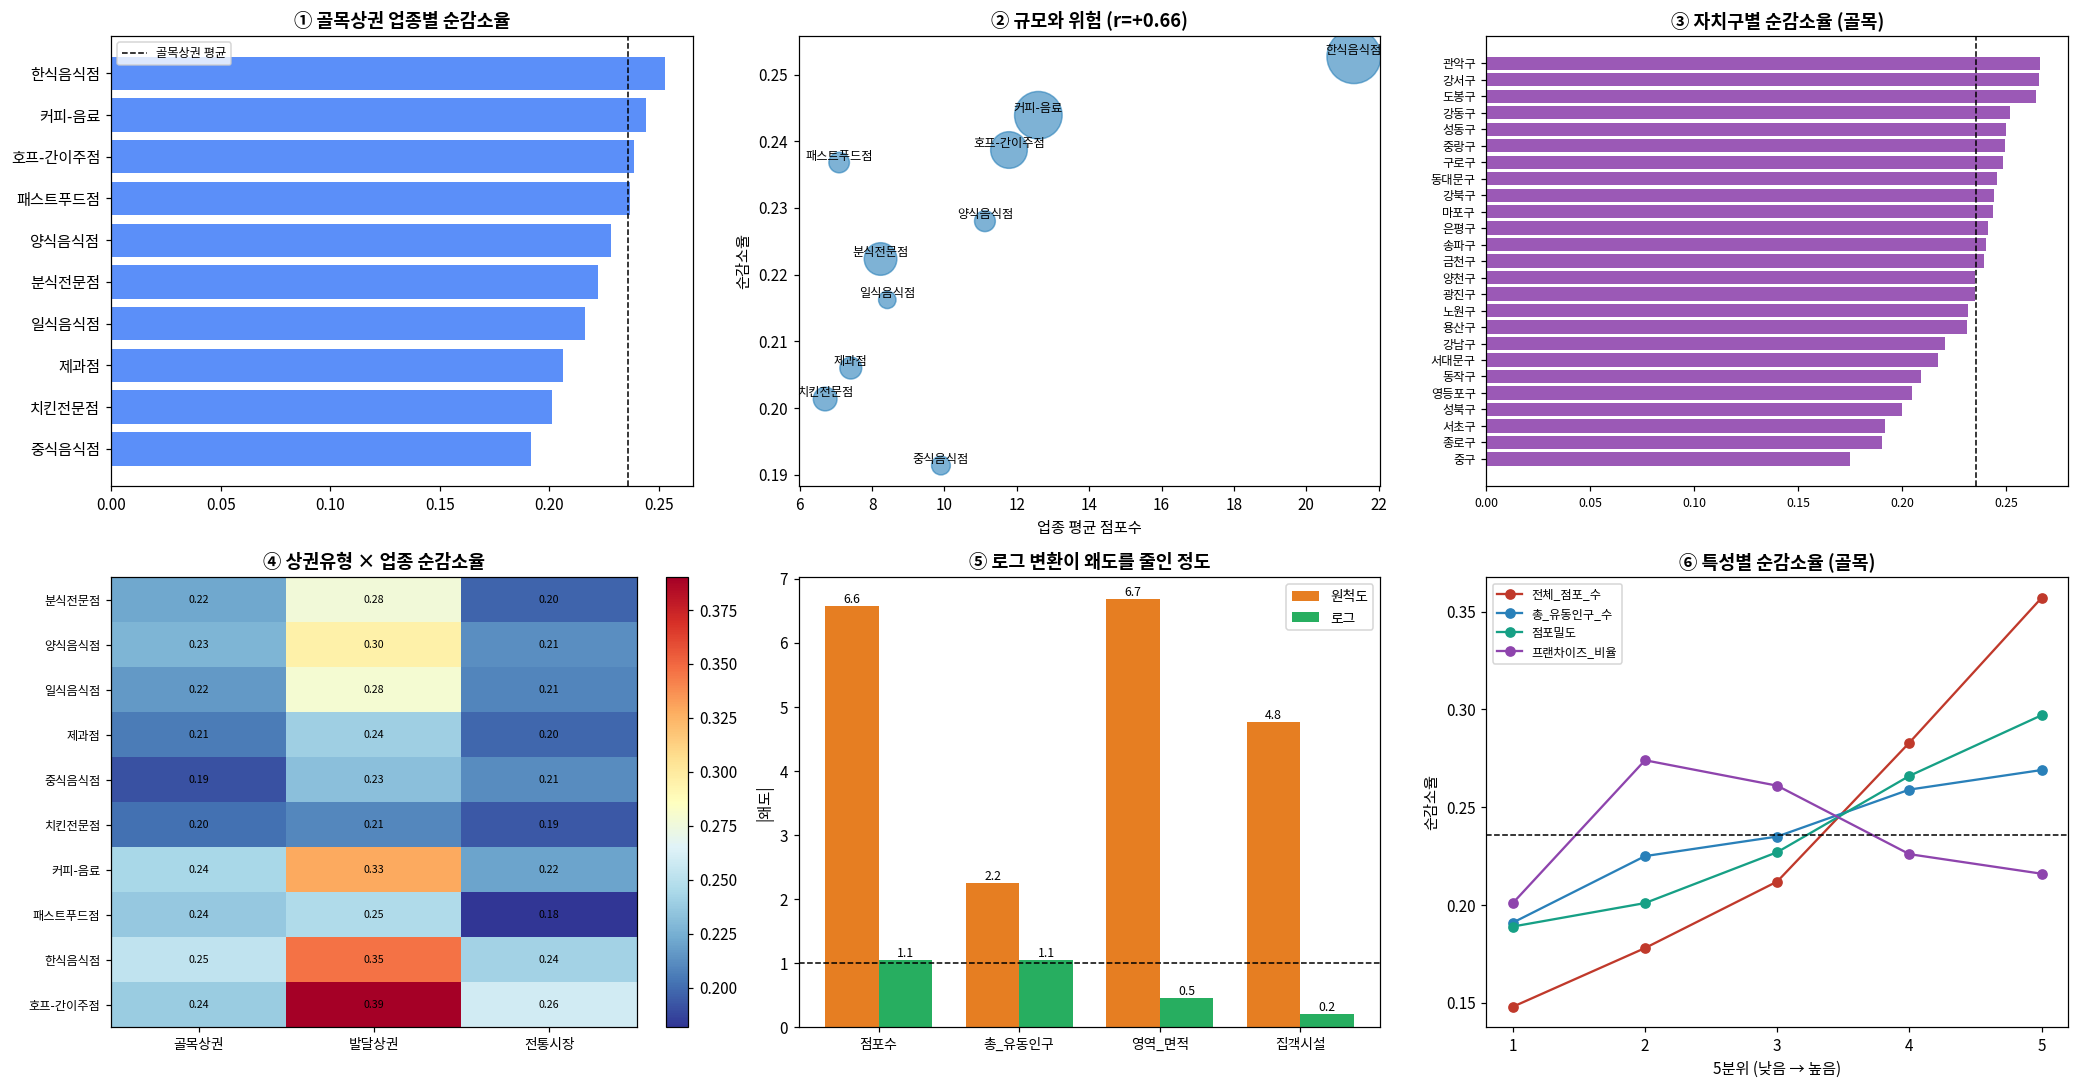

In [ ]:
fig, ax = plt.subplots(2, 3, figsize=(19, 10))

# ① 업종별 순감소율 (골목)
s = prof["순감소율"].sort_values()
ax[0,0].barh(s.index, s.values, color="#5b8ff9")
ax[0,0].axvline(gm["y"].mean(), ls="--", c="k", lw=1, label=f"{TARGET_TYPE} 평균")
ax[0,0].set_title(f"① {TARGET_TYPE} 업종별 순감소율", weight="bold")
ax[0,0].legend(fontsize=8)

# ② 규모 vs 위험
ax[0,1].scatter(prof["평균점포"], prof["순감소율"], s=prof["칸수"]/8, alpha=.6, c="#2980b9")
for i, row in prof.iterrows():
    ax[0,1].annotate(i, (row["평균점포"], row["순감소율"]), fontsize=8, ha="center", va="bottom")
ax[0,1].set_xlabel("업종 평균 점포수"); ax[0,1].set_ylabel("순감소율")
ax[0,1].set_title(f"② 규모와 위험 (r={r:+.2f})", weight="bold")

# ③ 자치구별
s = gu["순감소율"].sort_values()
ax[0,2].barh(s.index, s.values, color="#9b59b6")
ax[0,2].axvline(gm["y"].mean(), ls="--", c="k", lw=1)
ax[0,2].tick_params(labelsize=8)
ax[0,2].set_title("③ 자치구별 순감소율 (골목)", weight="bold")

# ④ 상권유형 × 업종 히트맵
hm = piv[["골목상권", "발달상권", "전통시장"]]
im = ax[1,0].imshow(hm.values, cmap="RdYlBu_r", aspect="auto")
ax[1,0].set_xticks(range(hm.shape[1])); ax[1,0].set_xticklabels(hm.columns, fontsize=9)
ax[1,0].set_yticks(range(hm.shape[0])); ax[1,0].set_yticklabels(hm.index, fontsize=8)
for i in range(hm.shape[0]):
    for j in range(hm.shape[1]):
        ax[1,0].text(j, i, f"{hm.values[i,j]:.2f}", ha="center", va="center", fontsize=7)
ax[1,0].set_title("④ 상권유형 × 업종 순감소율", weight="bold")
fig.colorbar(im, ax=ax[1,0], fraction=.046)

# ⑤ 로그 변환이 왜도를 얼마나 줄였나
pairs = list(zip(raw_cols, COVARIATES))
sk_raw = [abs(d[a].skew()) for a, _ in pairs]
sk_log = [abs(d[b].skew()) for _, b in pairs]
xp = np.arange(len(pairs)); w = 0.38
ax[1,1].bar(xp - w/2, sk_raw, w, label="원척도", color="#e67e22")
ax[1,1].bar(xp + w/2, sk_log, w, label="로그", color="#27ae60")
for k, (a, b) in enumerate(zip(sk_raw, sk_log)):
    ax[1,1].text(xp[k]-w/2, a, f"{a:.1f}", ha="center", va="bottom", fontsize=8)
    ax[1,1].text(xp[k]+w/2, b, f"{b:.1f}", ha="center", va="bottom", fontsize=8)
ax[1,1].axhline(1, ls="--", c="k", lw=1)
ax[1,1].set_xticks(xp)
ax[1,1].set_xticklabels([a.replace("_수", "").replace("전체_점포", "점포수")
                         for a, _ in pairs], fontsize=9)
ax[1,1].set_ylabel("|왜도|")
ax[1,1].set_title("⑤ 로그 변환이 왜도를 줄인 정도", weight="bold")
ax[1,1].legend(fontsize=9)

# ⑥ 분위별 순감소율
for v, c in [("전체_점포_수", "#c0392b"), ("총_유동인구_수", "#2980b9"),
             ("점포밀도", "#16a085"), ("프랜차이즈_비율", "#8e44ad")]:
    ax[1,2].plot(range(1, 6), quintile_profile(gm, v).values, marker="o", label=v, color=c)
ax[1,2].axhline(gm["y"].mean(), ls="--", c="k", lw=1)
ax[1,2].set_xticks(range(1, 6)); ax[1,2].set_xlabel("5분위 (낮음 → 높음)")
ax[1,2].set_ylabel("순감소율")
ax[1,2].set_title("⑥ 특성별 순감소율 (골목)", weight="bold"); ax[1,2].legend(fontsize=8)

plt.tight_layout()
plt.savefig(FIG / "step4_basic_eda.png", dpi=130)
plt.show()

## 4-9. 정리 — 다음 단계로 넘기는 것

In [ ]:
print("[STEP 5 로 넘길 것]")
print(f"  처리군 후보      : {prof['순감소율'].idxmax()} "
      f"({prof['순감소율'].max():.1%}, 2위와 격차 "
      f"{prof['순감소율'].max()-prof['순감소율'].nlargest(2).iloc[1]:+.1%}p)")
print(f"  규모↔위험 상관   : r = {r:+.3f}")
print(f"  매칭 공변량      : {', '.join(COVARIATES)}")
print()
print("[STEP 7(보조질문 2) 로 넘길 것]")
print(f"  매출 관측 표본   : {gm['매출_관측'].mean():.1%} (골목)")
print("  후보 변수        : 점포밀도, 외식_비중, 프랜차이즈_비율, 점포당매출, 자치구 고정효과")
print()
print("[STEP 8(H1) 로 넘길 것]")
print(f"  상권유형 간 최대 격차가 큰 업종 : "
      f"{piv['행내_최대차'].idxmax()} ({piv['행내_최대차'].max():.1%}p)")
print(f"[저장] figures/step4_basic_eda.png")

[STEP 5 로 넘길 것]
  처리군 후보      : 한식음식점 (25.3%, 2위와 격차 +0.9%p)
  규모↔위험 상관   : r = +0.657
  매칭 공변량      : log_점포수, log_유동인구, log_면적, log_집객시설

[STEP 7(보조질문 2) 로 넘길 것]
  매출 관측 표본   : 90.9% (골목)
  후보 변수        : 점포밀도, 외식_비중, 프랜차이즈_비율, 점포당매출, 자치구 고정효과

[STEP 8(H1) 로 넘길 것]
  상권유형 간 최대 격차가 큰 업종 : 호프-간이주점 (15.1%p)
[저장] figures/step4_basic_eda.png


---

## STEP 5 에서 할 일

- 골목상권으로 좁히고 업종별 순감소율로 **처리군을 데이터가 결정**
- 단순 격차 → 규모 교란 진단(규모 구간 고정) → SMD → 공통지지영역 → 단면 카이제곱
- 매칭 **전** SMD 가 크다는 것 자체가 "두 집단이 원래 다른 조건에 있다"는 증거이고, PSM 이 필요한 이유입니다
